# Задание №1.
В дизайн приложения были внесены изменения. Часть пользователей видела новый дизайн (тестовая группа), часть – стандартный (контрольная группа).

Данные содержатся в файле «AB_views_and_clicks.xlsx».

user_id – номер респондента

group – тип группы: контрольная или тестовая

views – количество просмотров

clicks – количество кликов

g_re –1-контрольная группа, 2-тестовая группа



1.1	Установите, есть ли статистически значимые различия по количеству кликов между экспериментальной (тестовой) и контрольной группами.

1.2	Установите, есть ли статистически значимые различия по количеству просмотров между экспериментальной (тестовой) и контрольной группами.

1.3	Установите, есть ли связь между количеством просмотров и количеством кликов в приложении.


In [ ]:
import pandas as pd
import numpy as np

df =  pd.read_excel('AB_views_and_clicks.xlsx')

In [ ]:
df.head()

,user_id,group,views,clicks,g_re
0,1,control,10,0,1
1,2,control,1,0,1
2,3,control,1,0,1
3,4,control,2,0,1
4,5,control,3,0,1


In [ ]:
df['group'].value_counts()

,count
group,
control,60000
test,60000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   user_id  120000 non-null  int64 
 1   group    120000 non-null  object
 2   views    120000 non-null  int64 
 3   clicks   120000 non-null  int64 
 4   g_re     120000 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 4.6+ MB


Для решения задач на сравнение средних в группах, выполните следующие пункты :
1. Сформулируйте содержательную гипотезу.
2. Проанализируйте необходимую описательную статистику и постройте подходящие графики.
3. Какой метод сравнения средних необходимо выбрать? Обоснуйте свой ответ.
4. Укажите проверяемую статистическую гипотезу для всех этапов анализа: сформулируйте гипотезы H0 и H1.
5. Проведите необходимые тесты и сделайте вывод по нулевой гипотезе. При необходимости проверьте вспомогательные нулевые гипотезы, которые помогут вам сделать вывод по основной.
6 Сделайте содержательный вывод о равенстве или различии в средних и, при необходимости, опишите характер этих различий.
7. Проверяйте гипотезы на уровне значимости 5%


1.1	Установите, есть ли статистически значимые различия по количеству кликов между экспериментальной (тестовой) и контрольной группами.

H0: Среднее количество кликов в тестовой группе равно среднему количеству в контрольной группе (разницы нет)

H1: Среднее количество кликов в тестовой группе не равно среднему количеству в контрольной группе

In [ ]:
desc1 = df.groupby('group')['clicks'].describe()
desc1

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control,60000.0,0.171717,0.453799,0.0,0.0,0.0,0.0,7.0
test,60000.0,0.193667,0.490337,0.0,0.0,0.0,0.0,9.0


В обеих группах распределение кликов крайне скошено в сторону нуля — у большинства пользователей кликов нет.
Это подтверждается медианой = 0 и тем, что 75% значений = 0.

In [ ]:
group1_control = df[df['group']=='control']['clicks']
group1_test = df[df['group']=='test']['clicks']
#формирование выборки

In [ ]:
stats.levene(group1_control.dropna(), group1_test.dropna())
#H0: дисперсии групп одинаковы
#H1: дисперсии групп различаются

LeveneResult(statistic=np.float64(64.76361644437048), pvalue=np.float64(8.520775106645593e-16))

Тест Левена оказался статистически значимым, что означает, что дисперсии в двух группах неодинаковы. Иными словами, тест отвергает нулевую гипотезу о равенстве дисперсий, подтверждая, что вариативность кликов в тестовой и контрольной группах различается. Это основание использовать Welch t-test, который не предполагает равенства дисперсий и считается более надёжным в таких условиях.

<Figure size 500x400 with 0 Axes>

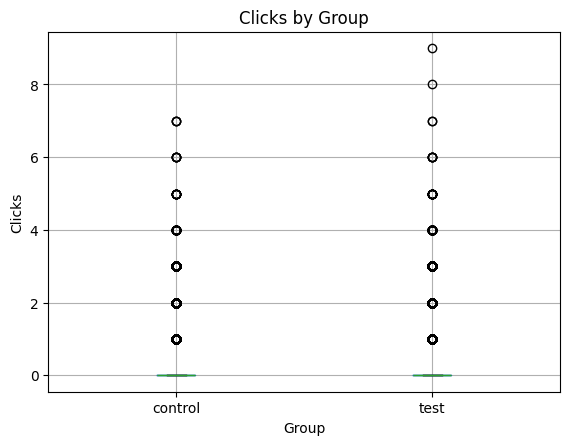

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats

plt.figure(figsize=(5,4))
df.boxplot(column='clicks', by='group')
plt.title('Clicks by Group')
plt.suptitle('')
plt.xlabel('Group')
plt.ylabel('Clicks')
plt.show()


График ящик с усами сравнивает распределение количества кликов между двумя группами. Видно, что медианные значения кликов в обеих группах находятся на уровне нулевых или близких к нулю значений, что говорит о низкой активности пользователей в целом. Однако разброс данных в тестовой группе несколько выше: присутствуют единичные наблюдения с количеством кликов до 9, тогда как в контрольной группе максимальные значения немного ниже. Это может указывать на то, что в тестовой группе отдельные пользователи проявили более высокую активность, хотя общая структура распределений остаётся схожей. В целом значимых визуальных отличий между группами не наблюдается, и для подтверждения гипотезы о различиях необходимо проведение статистического тестирования.

Welch t-test — это разновидность t-теста для сравнения средних в двух независимых группах, которая не требует равенства дисперсий между выборками. В отличие от классического t-теста Стьюдента, Welch t-test корректирует степень свободы и формулу стандартной ошибки таким образом, чтобы учесть различия в вариативности данных и размере групп. Мы используем именно Welch t-test в тех ситуациях, когда дисперсии в группах существенно отличаются или распределение данных заметно отклоняется от нормального — что характерно для наших данных по кликам. Из-за высокой асимметрии, большого количества нулей и разного разброса в тестовой и контрольной группах Welch t-test является более корректным и надёжным выбором для оценки разницы средних между группами.

In [ ]:
# Welcht-test
control = df[df.group=='control']['clicks']
testg = df[df.group=='test']['clicks']
ttest = stats.ttest_ind(control, testg, equal_var=False)
ttest


TtestResult(statistic=np.float64(-8.04758450992411), pvalue=np.float64(8.521233156657172e-16), df=np.float64(119285.51797311896))

Статистика t равна примерно -8.05, что указывает на значительную разницу между сравниваемыми выборками в стандартных отклонениях. p-значение очень мало, что значительно ниже обычного уровня значимости 0.05, поэтому нулевая гипотеза о равенстве средних отвергается. Это говорит о том, что различие между группами статистически значимо. Объем данных большой, что усиливает надежность полученного результата.

Итог: отвергаем H0, принимаем H1 - Среднее количество кликов в тестовой группе не равно среднему количеству в контрольной группе

1.2	Установите, есть ли статистически значимые различия по количеству просмотров между экспериментальной (тестовой) и контрольной группами.

H0: Среднее количество просмотров в тестовой и контрольной группах одинаково.

H1: Среднее количество просмотров в тестовой и контрольной группах различается.

In [ ]:
desc2 = df.groupby('group')['views'].describe()
desc2

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control,60000.0,4.95240,5.781752,1.0,2.0,3.0,6.0,131.0
test,60000.0,5.02975,6.045503,1.0,2.0,3.0,6.0,205.0


В контрольной и тестовой группах по 60 000 наблюдений. Среднее количество просмотров в тестовой группе (5.03) чуть выше, чем в контрольной (4.95), что указывает на небольшое увеличение активности в тестовой группе. Медианы обеих групп равны 3, а распределения имеют длинные хвосты (максимумы 131 и 205), что говорит о наличии редких пользователей с очень большим числом просмотров. Стандартное отклонение в тестовой группе немного больше, что отражает большую вариативность данных.

In [ ]:
group2_control = df[df['group']=='control']['views']
group2_test = df[df['group']=='test']['views']
#формирование выборки

In [ ]:
stats.levene(group2_control.dropna(), group2_test.dropna())
#H0: дисперсии групп одинаковы
#H1: дисперсии групп различаются

LeveneResult(statistic=np.float64(3.381479091135771), pvalue=np.float64(0.06593533008497207))

Тест Левена проверяет, равны ли дисперсии в контрольной и тестовой группах. Статистика теста ≈ 3.38, а p-значение ≈ 0.066. Так как p > 0.05, нет оснований отвергать нулевую гипотезу о равенстве дисперсий. Это означает, что вариативность (разброс) количества просмотров в обеих группах статистически не отличается, и для дальнейшего t-теста можно использовать стандартный подход без коррекции.

<Figure size 500x400 with 0 Axes>

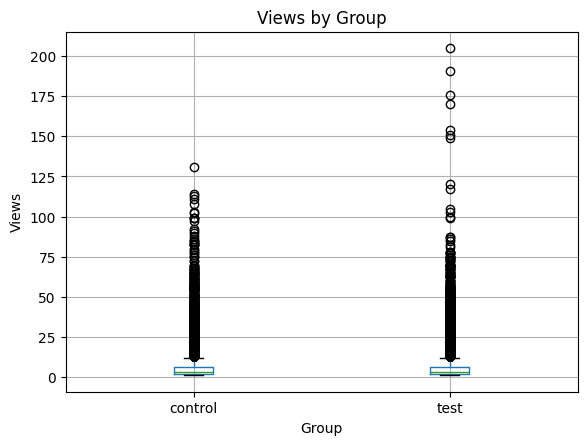

In [ ]:
plt.figure(figsize=(5,4))
df.boxplot(column='views', by='group')
plt.title('Views by Group')
plt.suptitle('')
plt.xlabel('Group')
plt.ylabel('Views')
plt.show()

Представленный boxplot демонстрирует распределение количества просмотров в контрольной и тестовой группах. В обеих группах медианные значения просмотров находятся на сопоставимом уровне, однако разброс данных значительно отличается: в обеих группах присутствует большое число выбросов, достигающих 150–200 просмотров, что указывает на сильную асимметрию распределения. Несмотря на наличие таких экстремальных значений, межквартильные размахи двух выборок практически совпадают, что визуально свидетельствует об отсутствии явных различий между группами. Только по графику нельзя сделать вывод о статистически значимом эффекте.

In [ ]:
stats.ttest_ind(group2_control.dropna(), group2_test.dropna())

TtestResult(statistic=np.float64(-2.2649520442300783), pvalue=np.float64(0.023517397783497894), df=np.float64(119998.0))

Результаты t-теста показывают, что статистика t ≈ -2.26, а p-значение ≈ 0.024. Так как p < 0.05, нулевая гипотеза о равенстве средних отвергается. Это означает, что количество просмотров в тестовой и контрольной группах различается статистически значимо. При этом отрицательное значение t указывает, что среднее количество просмотров в тестовой группе немного выше, чем в контрольной (с учетом знака сравнения), хотя разница не очень большая. Таким образом, эксперимент оказал статистически значимый, но умеренный эффект на просмотры.

Итог: H0 отвергается, принимается гипотеза H1 - Среднее количество просмотров в тестовой и контрольной группах различается.

Для решения задач на поиск связи между переменными, выполните следующие пункты:

1.	Сформулируйте содержательную гипотезу.

2.	Проанализируйте необходимую описательную статистику и постройте подходящие графики.

3.	Какой тип проверки гипотезы о наличии связи подходит в этом случае (коэффициент корреляции Пирсона, Спирмена или критерий Хи-квадрат)? Обоснуйте свой ответ.

4.	Укажите проверяемую статистическую гипотезу (H0) и альтернативную (H1).

5.	Проведите необходимые расчеты и сделайте вывод по нулевой гипотезе.

6.	Сделайте вывод о наличии или отсутствии связи между переменными и, если необходимо, опишите характер этой связи, а также содержательно проинтерпретируйте её.

7.	Проверяйте гипотезы на уровне значимости 5%


1.3	Установите, есть ли связь между количеством просмотров и количеством кликов в приложении.

H0: Между количеством просмотров и количеством кликов нет связи.

H1: Между количеством просмотров и количеством кликов есть связь.

In [ ]:
df[['views', 'clicks']].describe()

,views,clicks
count,120000.000000,120000.000000
mean,4.991075,0.182692
std,5.915200,0.472547
min,1.000000,0.000000
25%,2.000000,0.000000
50%,3.000000,0.000000
75%,6.000000,0.000000
max,205.000000,9.000000


В данных 120 000 наблюдений. Среднее количество просмотров составляет примерно 4.99, а среднее количество кликов — 0.18, что показывает, что клики происходят значительно реже, чем просмотры. Медиана просмотров равна 3, медиана кликов равна 0, а максимальные значения сильно выше средних (205 просмотров и 9 кликов), что указывает на наличие редких пользователей с очень высокой активностью. Стандартное отклонение также достаточно велико, особенно для просмотров (≈5.92), что отражает значительную вариативность данных. В целом, данные показывают, что большинство пользователей делают немного кликов и просмотров, а редкие активные пользователи создают длинные «хвосты» в распределении.

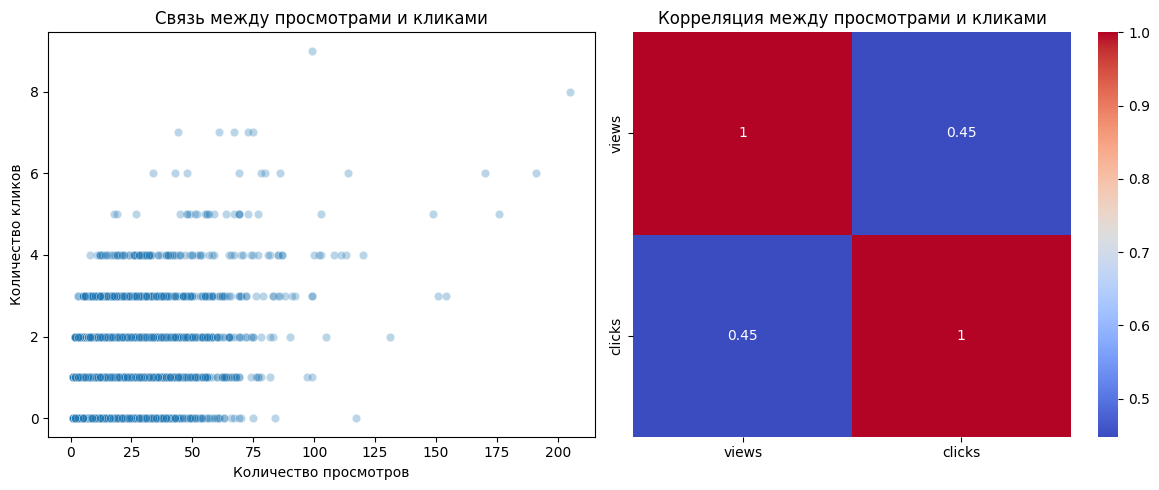

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(x='views', y='clicks', data=df, alpha=0.3)
plt.title('Связь между просмотрами и кликами')
plt.xlabel('Количество просмотров')
plt.ylabel('Количество кликов')

plt.subplot(1,2,2)
sns.heatmap(df[['views','clicks']].corr(), annot=True, cmap='coolwarm')
plt.title('Корреляция между просмотрами и кликами')

plt.tight_layout()
plt.show()

Scatter plot показывает зависимость между количеством просмотров и кликов. Видно, что с увеличением числа просмотров чаще наблюдается больше кликов, но большинство пользователей делают мало кликов, даже при большом числе просмотров. Также заметны редкие активные пользователи с большим числом просмотров и кликов, создающие «разброс» данных.

Heatmap корреляции показывает числовую оценку связи между переменными. Коэффициент корреляции Пирсона равен примерно 0.45, что подтверждает умеренную положительную линейную зависимость: увеличение просмотров связано с увеличением числа кликов.

В целом, графики наглядно демонстрируют, что между просмотрами и кликами существует статистически значимая связь, но она не является очень сильной.

In [ ]:
stats.pearsonr(df.views, df.clicks)

PearsonRResult(statistic=np.float64(0.44789103528966434), pvalue=np.float64(0.0))

Мы используем коэффициент корреляции Пирсона, потому что обе переменные количественные и непрерывные – количество просмотров и кликов можно считать числовыми, с большим диапазоном значений.

Коэффициент корреляции Пирсона между количеством просмотров и кликов равен примерно 0.448, что указывает на умеренную прямую связь: с увеличением просмотров количество кликов также, как правило, растет. p-значение равно 0.0, что значительно меньше уровня значимости 0.05, поэтому нулевую гипотезу о отсутствии связи отвергаем. Таким образом, можно сделать вывод, что между количеством просмотров и кликов существует статистически значимая положительная зависимость.

Итог: H0 отвергается, принимается H1 - Между количеством просмотров и количеством кликов есть связь.

# Задание №2.

В файле «treatment.xlsx» содержатся данные:

Age – возраст респондента

SleepHours – количество часов сна

ExerciseFrequencyDaysWeek – частота тренировок: сколько дней в неделю человек занимается физическими упражнениями.

RestingHeartRateBefore – частота пульса в состоянии покоя до принятия лекарства

RestingHeartRateAfter – частота пульса в состоянии покоя после принятия лекарства

MaxHeartRateDuringExercise – максимальная частота пульса во время тренировки

2.1 Установите, есть ли эффект от применения препарата.

2.2 Установите, есть ли взаимосвязь между количеством часов на сон и частотой пульса до применения препарата.


2.1 Установите, есть ли эффект от применения препарата.

In [ ]:
treatment =  pd.read_excel('treatment.xlsx')
treatment

,Age,SleepHours,ExerciseFrequencyDaysWeek,RestingHeartRateBefore,RestingHeartRateAfter,MaxHeartRateDuringExercise
0,37,9.1,7,78,71,142
1,46,7.8,5,80,73,153
2,27,7.1,3,56,50,153
3,51,10.7,4,67,61,145
4,32,6.6,6,85,76,140
...,...,...,...,...,...,...
495,18,3.8,2,78,70,159
496,54,8.9,3,65,60,137
497,49,6.5,6,72,64,141
498,42,4.2,2,77,72,148


In [ ]:
treatment[['RestingHeartRateAfter', 'RestingHeartRateBefore']].describe()

,RestingHeartRateAfter,RestingHeartRateBefore
count,500.000000,500.000000
mean,64.678000,71.640000
std,8.567913,8.373209
min,41.000000,45.000000
25%,59.000000,66.000000
50%,65.000000,72.000000
75%,70.000000,77.000000
max,93.000000,100.000000


После приёма препарата частота пульса в состоянии покоя заметно снизилась по сравнению с показателями до лечения. Среднее значение уменьшилось с 71,64 до 64,68, что отражает устойчивое снижение приблизительно на 7 ударов. Медиана и квартильные значения также сместились вниз, что указывает на общее снижение частоты пульса у большинства респондентов, а не только у отдельных случаев. Std практически не изменился, поэтому можно сказать, что препарат влияет на уровень пульса равномерно для разных участников. Минимальные и максимальные значения также показывают снижение, что подтверждает общую тенденцию. Эти результаты позволяют предположить, что препарат действительно оказывает эффект, снижая частоту пульса в состоянии покоя.

H0: У препарата нет эффекта (средний пульс до = среднему после)

H1: Препарат имеет эффект (средние различаются)

In [ ]:
from scipy import stats
stats.levene(treatment['RestingHeartRateAfter'].dropna(), treatment['RestingHeartRateBefore'].dropna())
#H0: дисперсии групп одинаковы
#H1: дисперсии групп различаются

LeveneResult(statistic=np.float64(0.03128426593582978), pvalue=np.float64(0.8596435730565823))

Так как p-value > 0.05, нет оснований отвергать нулевую гипотезу о равенстве дисперсий. Это означает, что разброс значений пульса до и после препарата статистически одинаковый. Препарат влияет на средний уровень пульса, но не изменяет вариативность показателей — люди реагируют на него достаточно равномерно.

Так как данные представляют собой повторные измерения у одних и тех же респондентов, необходимо применять парный t-тест, который сравнивает средние значения связанных выборок. Дополнительно тест Левена показал, что дисперсии значимо не различаются (p = 0.86), что подтверждает корректность использования параметрического t-теста.

In [ ]:
import scipy.stats as stats

stats.ttest_rel(
    treatment["RestingHeartRateBefore"],
    treatment["RestingHeartRateAfter"],
    alternative='two-sided'
)

TtestResult(statistic=np.float64(80.54043235396121), pvalue=np.float64(4.106358433141536e-288), df=np.int64(499))

Результаты парного t-теста показывают, что различия между частотой пульса до и после приёма препарата являются статистически значимыми. Значение t-статистики составляет 80.54, что указывает на крайне сильное отличие средних. p-value практически равно нулю, что значительно меньше уровня значимости 0.05. Это означает, что вероятность получить такое различие случайно практически отсутствует.

Таким образом, можно уверенно заключить, что препарат оказывает выраженный эффект на снижение частоты пульса в состоянии покоя, и нулевая гипотеза об отсутствии изменений отвергается.

2.2 Установите, есть ли взаимосвязь между количеством часов на сон и частотой пульса до применения препарата.

H0: Между количеством часов сна и частотой пульса до применения препарата нет линейной связи.

H1: Между количеством часов сна и частотой пульса до применения препарата существует линейная связь.

Проверка на нормальность для определения нужного коэф корреляции

In [ ]:
stats.kstest(treatment["SleepHours"].dropna(),'norm', args=(treatment["SleepHours"].mean(), treatment["SleepHours"].std()))

KstestResult(statistic=np.float64(0.027563486148282024), pvalue=np.float64(0.8315885278528512), statistic_location=np.float64(6.4), statistic_sign=np.int8(1))

H0 - распределение переменной SleepHours не отличается от нормального

H1 - распределение переменной SleepHours отличается от нормального

pvalue = 0.83

уровень значимости = 0.05

pvalue > 0.05, следовательно H0  не отвергается

Вывод: принимаем гипотезу H0 о нормальности распредления

/tmp/ipython-input-3364656647.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(treatment["SleepHours"].dropna(), fit=stats.norm)


<Axes: xlabel='SleepHours', ylabel='Density'>

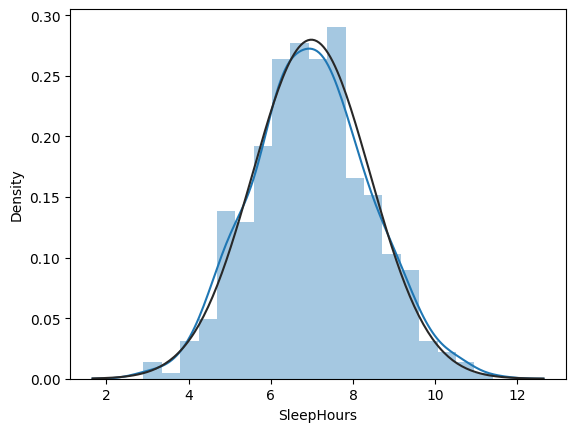

In [ ]:
import seaborn as sns
from scipy import stats
sns.distplot(treatment["SleepHours"].dropna(), fit=stats.norm)

Гистограмма с наложенной кривой показывает распределение количества часов сна в выборке. Распределение визуально близко к нормальному: оно симметрично вокруг среднего значения (примерно 7 часов), имеет характерный «колокол» и постепенно убывает к краям. Большинство наблюдений сосредоточено в диапазоне от 6 до 8 часов, в то время как значения ниже 4 и выше 10 часов встречаются значительно реже, что отражает наличие небольшого количества выбросов. Наложенная нормальная кривая также указывает, что данные хорошо согласуются с предположением о нормальности, что позволяет использовать параметрические методы статистического анализа для дальнейших проверок.

In [ ]:
stats.kstest(treatment["RestingHeartRateBefore"].dropna(),'norm', args=(treatment["RestingHeartRateBefore"].mean(), treatment["RestingHeartRateBefore"].std()))

KstestResult(statistic=np.float64(0.05071503817538714), pvalue=np.float64(0.14757472128719273), statistic_location=np.int64(76), statistic_sign=np.int8(-1))

H0 - распределение переменной SleepHours не отличается от нормального

H1 - распределение переменной SleepHours отличается от нормального

pvalue = 0.147

уровень значимости = 0.05

pvalue > 0.05, следовательно H0  не отвергается

Вывод: принимаем гипотезу H0 о нормальности распредления

/tmp/ipython-input-3250116754.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(treatment["RestingHeartRateBefore"].dropna(), fit=stats.norm)


<Axes: xlabel='RestingHeartRateBefore', ylabel='Density'>

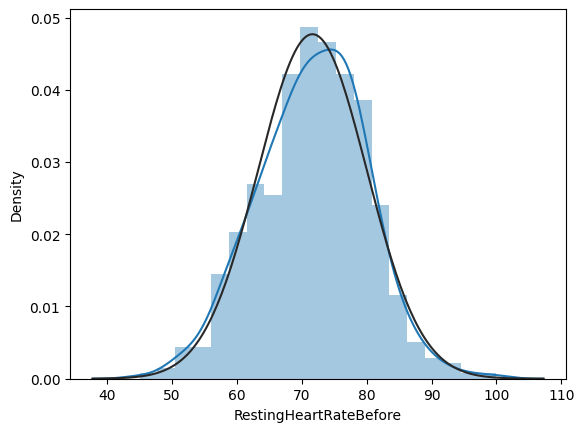

In [ ]:
import seaborn as sns
from scipy import stats
sns.distplot(treatment["RestingHeartRateBefore"].dropna(), fit=stats.norm)

Большинство значений сосредоточено вокруг 70 ударов в минуту, что видно по высокой центральной колонке. Форма распределения близка к нормальной: плавная симметричная кривая, подогнанная нормальным распределением, хорошо ложится на данные. Заметны небольшие отклонения по краям (более редкие значения около 50 и 100), но данные выглядят достаточно однородными и без выраженных выбросов. Это говорит о том, что переменная распределена примерно нормально и может подходить для параметрических статистических методов.

Распределение обеих переменных нормально без ярких выбросов, значит используем коэф. корреляции Пирсона.

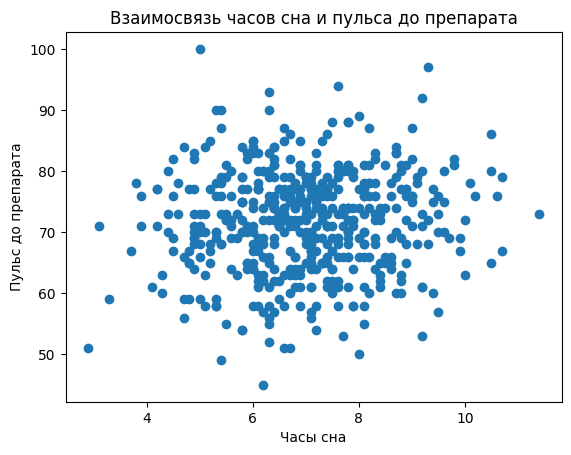

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(treatment["SleepHours"], treatment["RestingHeartRateBefore"])
plt.xlabel("Часы сна")
plt.ylabel("Пульс до препарата")
plt.title("Взаимосвязь часов сна и пульса до препарата")
plt.show()


График рассеяния говорит о том, что количество часов сна практически не влияет на частоту пульса до применения препарата. Линия связи, если её провести, была бы почти горизонтальной, что подтверждает слабую взаимосвязь между переменными.

In [ ]:
stats.pearsonr(treatment["SleepHours"], treatment["RestingHeartRateBefore"])

PearsonRResult(statistic=np.float64(0.08550308195766039), pvalue=np.float64(0.056053193875246425))

Коэффициент корреляции Пирсона равен 0,086, что указывает на крайне слабую положительную связь между часами сна и пульсом до лекарства. Значение p-value равно 0,056, немного выше стандартного уровня значимости 0,05. Это означает, что статистических оснований отвергнуть нулевую гипотезу нет.

Таким образом, можно сделать вывод, что значимой линейной взаимосвязи между количеством часов сна и частотой пульса до применения препарата не обнаружено.

Итог: Между количеством часов сна и частотой пульса до применения препарата нет линейной связи.

# Задание №3.
В сети магазинов запустили 3 типа рекламы. Для каждого магазина провели свою рекламную компанию, обобщили данные и попытались узнать, как они повлияли на объемы продаж по магазинам.

Данные содержатся в файле «trade.xlsx»

MarketID – идентификатор рынка

MarketSize – размер магазина (Large, Medium, Small)

LocationID – уникальный идентификатор конкретного магазина

AgeOfStore – возраст магазина

Promotion – тип рекламной кампании (тип маркетинговой активности), используемой в магазине (например, скидка, акция 2+1, реклама)

Week – номер недели наблюдения за магазином

SalesInThousands – объем продаж магазина за неделю (в тыс. руб.)

SizeMarket – размер магазина: 1 – Large, 2 – Medium, 3 – Small

3.1 Установите, есть ли взаимосвязь между типом продвижения (Promotion) и итоговыми продажами (SalesInThousands).

3.2 Установите, есть ли взаимосвязь между размером магазина и итоговыми продажами.


3.1 Установите, есть ли взаимосвязь между типом продвижения (Promotion) и итоговыми продажами (SalesInThousands).

H0: тип продвижения (Promotion) не влияет на средние продажи (SalesInThousands), то есть средние продажи во всех группах одинаковы.

H1: тип продвижения влияет на средние продажи, то есть хотя бы в одной группе средние продажи отличаются.

In [ ]:
import pandas as pd
from scipy import stats

trade = pd.read_excel('trade.xlsx')
trade

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands,SizeMarket
0,1,Medium,1,4,3,1,33.73,2
1,1,Medium,1,4,3,2,35.67,2
2,1,Medium,1,4,3,3,29.03,2
3,1,Medium,1,4,3,4,39.25,2
4,1,Medium,2,5,2,1,27.81,2
...,...,...,...,...,...,...,...,...
543,10,Large,919,2,1,4,64.34,1
544,10,Large,920,14,2,1,50.20,1
545,10,Large,920,14,2,2,45.75,1
546,10,Large,920,14,2,3,44.29,1


In [ ]:
trade[['Promotion', 'SalesInThousands']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Promotion         548 non-null    int64  
 1   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 8.7 KB


In [ ]:
trade[['Promotion', 'SalesInThousands']].describe()

,Promotion,SalesInThousands
count,548.000000,548.000000
mean,2.029197,53.466204
std,0.810729,16.755216
min,1.000000,17.340000
25%,1.000000,42.545000
50%,2.000000,50.200000
75%,3.000000,60.477500
max,3.000000,99.650000


На основе предоставленной статистики можно сделать следующие выводы. Данные включают 548 наблюдений по продажам и типу продвижения. Средний объём продаж составляет около 53,5 тыс. руб., при этом стандартное отклонение равно 16,8 тыс. руб., что указывает на умеренную вариативность продаж между магазинами. Минимальное значение продаж — 17,3 тыс. руб., а максимальное — 99,7 тыс. руб., что показывает широкий диапазон результатов. Медиана продаж (50,2 тыс. руб.) немного ниже среднего, что говорит о лёгкой положительной асимметрии распределения. Значения типа Promotion варьируются от 1 до 3, при этом 25-й, 50-й и 75-й перцентили равны 1, 2 и 3 соответственно, что указывает на равномерное распределение наблюдений по трем типам продвижения. Эти данные позволяют предположить, что различия в продажах могут быть связаны с типом Promotion, однако для подтверждения необходима статистическая проверка (например, ANOVA).

In [ ]:
desc3 = trade.groupby('Promotion')['SalesInThousands'].describe()
desc3

,count,mean,std,min,25%,50%,75%,max
Promotion,,,,,,,,
1,172.0,58.099012,16.553782,30.81,46.3525,55.385,63.6175,99.65
2,188.0,47.329415,15.108955,17.34,38.1700,45.385,51.7450,88.64
3,188.0,55.364468,16.766231,22.18,44.1975,51.165,61.7325,96.48


На основе групповой статистики по типам Promotion можно сделать следующие выводы. Продажи магазинов с Promotion 1 в среднем составляют 58,1 тыс. руб., что выше среднего по всем наблюдениям, при стандартном отклонении 16,6 тыс. руб. Продажи с Promotion 2 в среднем ниже — 47,3 тыс. руб., с меньшей вариативностью (стандартное отклонение 15,1 тыс. руб.). Для Promotion 3 средние продажи составляют 55,4 тыс. руб., с вариативностью 16,8 тыс. руб. Медианные значения подтверждают ту же тенденцию: Promotion 1 имеет наибольшие медианные продажи (55,4 тыс. руб.), Promotion 2 — наименьшие (45,4 тыс. руб.), Promotion 3 — промежуточные (51,2 тыс. руб.). Диапазон значений продаж показывает, что независимо от типа Promotion встречаются как низкие, так и высокие продажи, однако в среднем Promotion 1 демонстрирует наибольшую эффективность, а Promotion 2 — наименьшую. Это указывает на существование различий в продажах в зависимости от типа продвижения, которые могут быть статистически значимыми.

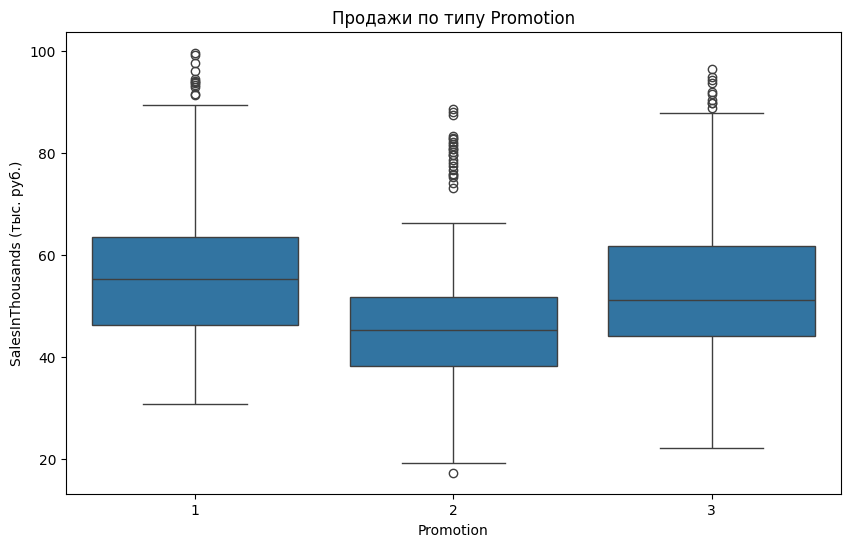

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Promotion', y='SalesInThousands', data=df)
plt.title('Продажи по типу Promotion')
plt.ylabel('SalesInThousands (тыс. руб.)')
plt.xlabel('Promotion')
plt.show()

Для проверки того, влияет ли тип продвижения (Promotion) на уровень продаж (SalesInThousands), используется ANOVA (Analysis of Variance). Это связано с тем, что независимая переменная Promotion является категориальной с тремя уровнями (1, 2, 3), а зависимая переменная SalesInThousands — количественная. ANOVA позволяет одновременно сравнить средние значения продаж между всеми группами и определить, существуют ли статистически значимые различия, не проводя множество попарных t-тестов, что снижает риск ошибок.

Таким образом, данный метод оценивает, объясняет ли тип продвижения значительную часть вариации продаж по сравнению с внутригрупповой вариативностью, и является оптимальным инструментом для проверки влияния Promotion на продажи.

In [ ]:
trade_1 = trade[trade['Promotion']== 1]['SalesInThousands']
trade_2 = trade[trade['Promotion']== 2]['SalesInThousands']
trade_3 = trade[trade['Promotion']== 3]['SalesInThousands']

In [ ]:
stats.f_oneway(trade_1, trade_2, trade_3)

F_onewayResult(statistic=np.float64(21.953485793080674), pvalue=np.float64(6.765849261408714e-10))

Мы выолняем ANOVA (односторонний дисперсионный анализ) для проверки того, есть ли статистически значимые различия в средних продажах между тремя типами продвижения (Promotion).

F = 21.95 — говорит о том, что межгрупповая вариативность (различия между типами Promotion) значительно больше внутригрупповой вариативности.

p-value < 0.05 — это крайне низкое значение, что указывает на статистически значимую разницу в продажах между типами продвижения.

Можно сделать вывод, что тип Promotion действительно влияет на продажи: средние продажи различаются между группами, и эти различия не случайны. Принимаем гипотезу H1.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
print(pairwise_tukeyhsd(trade['SalesInThousands'], trade['Promotion']))

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


1 vs 2: разница средних продаж = 10,77 тыс. руб., p < 0.05 - значимая, продажи при Promotion 1 выше, чем при Promotion 2.

1 vs 3: разница средних = 2,73 тыс. руб., p > 0.05 - незначимая, средние продажи примерно равны.

2 vs 3: разница средних = 8,04 тыс. руб., p < 0.05 - значимая, продажи при Promotion 3 выше, чем при Promotion 2.

После проведения ANOVA для проверки различий в средних продажах между типами продвижения был выполнен пост-хок анализ Тьюки, чтобы определить, какие именно группы отличаются. Результаты показали, что средние продажи при Promotion 1 значительно выше, чем при Promotion 2, а продажи при Promotion 3 также выше, чем при Promotion 2. Разница между Promotion 1 и Promotion 3 статистически незначима, что означает примерно равный уровень продаж для этих типов.

Итог: существует взаимосвязь между типом продвижения и продажами. Наиболее эффективный тип продвижения — Promotion 1, наименее эффективный — Promotion 2, а Promotion 3 демонстрирует средний уровень продаж.

3.2 Установите, есть ли взаимосвязь между размером магазина и итоговыми продажами.

H0: размер магазина (SizeMarket) не влияет на средние продажи (SalesInThousands), то есть средние продажи одинаковы для всех размеров магазинов.

H1: размер магазина влияет на средние продажи, то есть хотя бы в одной группе средние продажи отличаются от других.

In [ ]:
desc4 = trade.groupby('SizeMarket')['SalesInThousands'].describe()
desc4

,count,mean,std,min,25%,50%,75%,max
SizeMarket,,,,,,,,
1,168.0,70.116726,17.052156,39.36,53.6225,75.020,84.5325,99.65
2,320.0,43.985344,9.051378,17.34,37.9225,44.590,50.3450,65.11
3,60.0,57.409333,6.633101,36.17,53.3425,57.555,62.1600,70.60


На основе описательной статистики можно сделать следующие выводы. Средние продажи магазинов зависят от их размера: для крупных магазинов (SizeMarket 1) средние продажи составляют около 70,1 тыс. руб., что значительно выше, чем для средних магазинов (SizeMarket 2) — 44,0 тыс. руб. и малых магазинов (SizeMarket 3) — 57,4 тыс. руб. Стандартное отклонение показывает, что вариативность продаж на крупных магазинах (17,1 тыс. руб.) выше, чем на средних (9,1 тыс. руб.) и малых (6,6 тыс. руб.) магазинах. Медианные значения подтверждают ту же тенденцию: 75,0 тыс. руб. у крупных, 44,6 тыс. руб. у средних и 57,6 тыс. руб. у малых. Диапазоны продаж показывают, что независимо от размера встречаются как низкие, так и высокие продажи, но в среднем крупные магазины продают больше всего, средние — меньше всего, а малые занимают промежуточное положение. Это указывает на существование взаимосвязи между размером магазина и уровнем продаж.

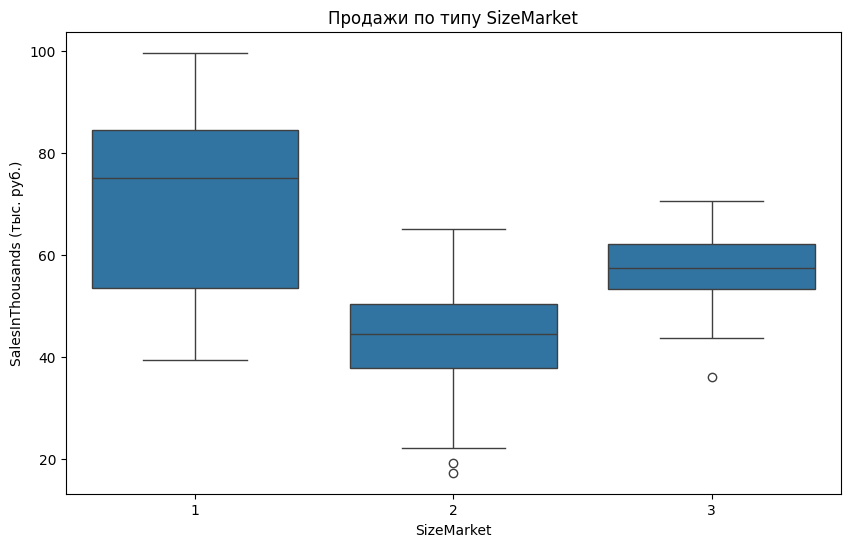

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='SizeMarket', y='SalesInThousands', data=df)
plt.title('Продажи по типу SizeMarket')
plt.ylabel('SalesInThousands (тыс. руб.)')
plt.xlabel('SizeMarket')
plt.show()

Ящики с усами показывают распределение продаж (SalesInThousands) по трем категориям размера магазина (SizeMarket). Видно, что крупные магазины (SizeMarket 1) имеют самые высокие средние продажи, широкий диапазон и более высокие медианные значения. Средние магазины (SizeMarket 2) демонстрируют наименьшие средние продажи и более узкий разброс, а малые магазины (SizeMarket 3) занимают промежуточное положение.

In [ ]:
trade_m1 = trade[trade['SizeMarket']== 1]['SalesInThousands']
trade_m2 = trade[trade['SizeMarket']== 2]['SalesInThousands']
trade_m3 = trade[trade['SizeMarket']== 3]['SalesInThousands']

In [ ]:
stats.f_oneway(trade_m1, trade_m2, trade_m3)

F_onewayResult(statistic=np.float64(268.9130229516846), pvalue=np.float64(5.633818717739379e-82))

Результаты ANOVA: F = 268.91, p < 0.05, что указывает на статистически значимые различия в средних продажах между различными размерами магазинов.

Вывод: существует взаимосвязь между размером магазина и итоговыми продажами. Крупные магазины продают значительно больше, средние — меньше всего, малые магазины показывают средний уровень продаж.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
print(pairwise_tukeyhsd(trade['SalesInThousands'], trade['SizeMarket']))

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
     1      2 -26.1314   0.0 -28.7979 -23.4649   True
     1      3 -12.7074   0.0 -16.9165  -8.4982   True
     2      3   13.424   0.0   9.4867  17.3613   True
-----------------------------------------------------


Выполнен тест Тьюки для множественного сравнения средних продаж (SalesInThousands) между тремя группами по размеру рынка (SizeMarket). Результаты показывают разницу между средними значениями продаж каждой пары групп, доверительные интервалы и значимость различий.

Между группой 1 и группой 2 разница в среднем составляет −26,13 тыс., что статистически значимо (p < 0,05), значит продажи в группе 2 значительно выше.

Между группой 1 и группой 3 разница −12,71 тыс., также значима, то есть группа 3 имеет выше продажи, чем группа 1.

Между группой 2 и группой 3 разница +13,42 тыс., значима, что показывает, что группа 2 имеет больше продаж, чем группа 3.

Итог: все различия между группами статистически значимы, что указывает на влияние размера рынка на уровень продаж. Т.е. нулевая гипотеза отвергается, принимается H1 - размер магазина действительно влияет на средние продажи.